# Neural Networks 
In this model, two training methods are explored:
1. Baseline Training with SGD 
2. Optimised Training with Adam Optimiser

Upon the training, parameter tunning is then performed to optimise the performance. 

In [132]:
# import the logger to log results
from util import log_result

In [133]:

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


try:
    import keras
except Exception:
    try:
        import tensorflow as tf
        keras = tf.keras
    except Exception:
        import sys, subprocess
        subprocess.check_call([sys.executable, "-m", "pip", "install", "tensorflow"])
        import tensorflow as tf
        keras = tf.keras
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Dense, Dropout, Flatten
try:
    from keras.layers import Conv2D, MaxPooling2D
except Exception:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "tensorflow", "keras"])
    from keras.layers import Conv2D, MaxPooling2D
from keras import backend as K

import random
%matplotlib inline

# import latexing for pretty tables and markdown in jupyter notebooks
from IPython.display import display, Markdown, Latex

# Section 0: Load the Training Data + Initialisation

## 0.1 Data Loading 

In [134]:
# Load the training data.
Data_path="final_clean_train_df.csv"
target_column="readmitted"
train_df = pd.read_csv(Data_path)
print("Data loaded successfully.")
print("Training data shape:", train_df.shape)
print("Target column:", target_column)
print("columns:", list(train_df.columns))
train_df.head()

Data loaded successfully.
Training data shape: (91589, 78)
Target column: readmitted
columns: ['Unnamed: 0.1', 'number_inpatient_log', 'number_inpatient_sqrt', 'number_inpatient', 'number_emergency_log', 'number_emergency_sqrt', 'discharge_disposition_id_11', 'number_diagnoses', 'number_emergency', 'number_outpatient', 'admission_source_id_7', 'discharge_disposition_id_22', 'num_medications_log', 'discharge_disposition_id_1', 'time_in_hospital_log', 'time_in_hospital_sqrt', 'num_medications_sqrt', 'discharge_disposition_id_6', 'diabetesMed_Yes', 'admission_source_id_6', 'time_in_hospital', 'diag_2_Diabetes', 'medical_specialty_Other', 'admission_source_id_4', 'admission_type_id_3', 'num_medications', 'insulin_Down', 'diag_3_Diabetes', 'insulin_No', 'is_weight_recorded', 'diag_1_Neoplasms', 'num_procedures_sqrt', 'num_procedures_log', 'discharge_disposition_id_3', 'change_Ch', 'num_procedures', 'insulin_Up', 'num_lab_procedures', 'medical_specialty_Unknown', 'payer_code_BC', 'admission_

,Unnamed: 0.1,number_inpatient_log,number_inpatient_sqrt,number_inpatient,number_emergency_log,number_emergency_sqrt,discharge_disposition_id_11,number_diagnoses,number_emergency,number_outpatient,...,glipizide_No,diag_3_Circulatory,glipizide_Steady,race_Other,gender_Female,diag_3_Respiratory,diag_2_Respiratory,diag_1_Injury,readmitted,patient_nbr
0,0,0.000000,0.0,0,0.0,0.0,0,9,0,0,...,1,0,0,0,1,0,0,0,>30,55629189
1,1,0.693147,1.0,1,0.0,0.0,0,6,0,2,...,0,0,1,0,1,0,0,0,NO,86047875
2,2,0.000000,0.0,0,0.0,0.0,0,7,0,0,...,1,1,0,0,0,0,0,0,NO,82442376
3,3,0.000000,0.0,0,0.0,0.0,0,5,0,0,...,0,0,1,0,0,0,0,0,NO,42519267
4,4,0.000000,0.0,0,0.0,0.0,0,9,0,0,...,1,0,0,0,0,0,0,0,>30,82637451


In [135]:
# drop the patient_nbr column  and keep it only for grouping, not as a feature
# separate features (X), target (y), and groups (patient-level)
target_column = "readmitted"

# Keep patient_nbr ONLY for grouping (NOT as a feature)
assert "patient_nbr" in train_df.columns, "patient_nbr missing from train_df"
groups = train_df["patient_nbr"].to_numpy()

# Drop target + patient_nbr from features
X_df = train_df.drop(columns=[target_column, "patient_nbr"])
y = train_df[target_column]

# Convert to numpy
X = X_df.to_numpy(dtype=np.float32)
y = y.to_numpy()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("groups shape:", groups.shape)

X shape: (91589, 76)
y shape: (91589,)
groups shape: (91589,)


In [136]:
# encode labels to class indices
label_map = {'<30': 0, '>30': 1, 'NO': 2}
# apply the label map to the target array
y_idx = np.vectorize(label_map.get)(y)
print("y_idx shape:", y_idx.shape)
print("unique classes:", np.unique(y_idx))
# convert to categorical one-hot encoding
num_classes = 3
y_onehot= keras.utils.to_categorical(y_idx, num_classes=num_classes).astype(np.float32)
print("y_onehot shape:", y_onehot.shape)
print("First 5 rows of y_onehot:\n", y_onehot[:5])



y_idx shape: (91589,)
unique classes: [0 1 2]
y_onehot shape: (91589, 3)
First 5 rows of y_onehot:
 [[0. 1. 0.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 1. 0.]]


In [137]:


X_train, X_val = X[train_idx], X[val_idx]
y_train, y_val = y[train_idx], y[val_idx]


mean = X_train.mean(axis=0)
std = X_train.std(axis=0) + 1e-8  # numerical safety


X_train = (X_train - mean) / std
X_val   = (X_val   - mean) / std

print("X standardized mean (first 5 features):", np.mean(X_train, axis=0)[:5])
print("X standardized std (first 5 features):", np.std(X_train, axis=0)[:5])


X standardized mean (first 5 features): [ 8.6684831e-06 -4.2209671e-05  4.3612781e-07 -2.4050445e-05
 -1.0265535e-05]
X standardized std (first 5 features): [0.99999833 1.000071   1.0003523  1.0000061  0.99990684]


## 0.2 Set K value for Cross Validation. 

K-1 folds for training and 1 fold for validation. Final performance will be the average over K runs. K=10 is used here, as, according to the lecture note, it is a standard default associated with low bias of validation error and acceptable computational cost.


In [138]:
from sklearn.model_selection import StratifiedGroupKFold
# 42 is a random seed for reproducibility
skf = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=42) 
folds=[]

# Determine grouping column robustly: use patient_nbr if present, otherwise fall back to

if 'patient_nbr' in train_df.columns:
    groups = train_df['patient_nbr'].to_numpy()
    print("Using train_df['patient_nbr'] as groups for StratifiedGroupKFold.")
for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X, y, groups=groups)):
    folds.append((train_idx, val_idx))
    print(f"Fold {fold_idx}: Train size = {len(train_idx)}, validation size = {len(val_idx)}")

Using train_df['patient_nbr'] as groups for StratifiedGroupKFold.
Fold 0: Train size = 82071, validation size = 9518
Fold 1: Train size = 82299, validation size = 9290
Fold 2: Train size = 82288, validation size = 9301
Fold 3: Train size = 82422, validation size = 9167
Fold 4: Train size = 82329, validation size = 9260
Fold 5: Train size = 82550, validation size = 9039
Fold 6: Train size = 82614, validation size = 8975
Fold 7: Train size = 82638, validation size = 8951
Fold 8: Train size = 82569, validation size = 9020
Fold 9: Train size = 82521, validation size = 9068


# Section 1: Building the Model

## Activation functions + derivatives

In [139]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))
def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)
def relu(x):
    return np.maximum(0, x)
def relu_derivative(x):
    return np.where(x > 0, 1, 0)
def leaky_relu(x, alpha=0.01):
    return np.where(x > 0, x, alpha * x)
def leaky_relu_derivative(x, alpha=0.01):
    return np.where(x > 0, 1, alpha)
def softmax(x):
    exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

## Define the loss functions - multiclass cross-entropy 

### 1. Create Multiclass Cross-Entropy
For the 3-class classification task (<30, >30, NO), we use multiclass cross-entropy with one-hot encoded labels.  
Given logits $\mathbf{z}_i \in \mathbb{R}^C$, softmax probabilities are computed as:
$$
p_{i,c} = \frac{\exp(z_{i,c})}{\sum_{k=1}^{C} \exp(z_{i,k})}
$$

The standard cross-entropy loss over a batch of $N$ samples is:

$$
\mathcal{L}_{\text{CE}} =
-\frac{1}{N}
\sum_{i=1}^{N}
\sum_{c=1}^{C}
y_{i,c}\,\log(p_{i,c})
$$

where probabilities are clipped by a small $\varepsilon$ to ensure numerical stability.

In [140]:
def cross_entropy_loss(y_true, y_pred, esp=1e-15):
    # parameters: Y_true: true labels in one-hot encoding, shape (m, num_classes)
    #             Y_pred: predicted logits (before softmax), shape (m, num_classes)
    #             esp: small value to avoid log(0)
    # m being the number of samples in one batch.
    m = y_true.shape[0]
    # apply softmax to convert logits to probabilities
    p = softmax(y_pred)
    # clip probabilities to avoid log(0)
    p = np.clip(p, esp, 1.0)
    log_likelihood = -np.log(p[range(m), np.argmax(y_true, axis=1)] + esp)
# compute the average cross-entropy loss
    loss = np.sum(log_likelihood) / m
    return loss
# quick test of the loss function, should be close to 1.0986 (ln(1/3)) for 3 classes with random predictions
y_test_true = np.array([[1,0,0],[0,1,0],[0,0,1]])
y_test_pred = np.random.randn(3,3)
loss_test = cross_entropy_loss(y_test_true, y_test_pred)
print("Test cross-entropy loss (should be close to 1.0986):", loss_test)
print("y_onehot shape:", y_test_true.shape)


Test cross-entropy loss (should be close to 1.0986): 1.6991061292610077
y_onehot shape: (3, 3)


### 2. Define the class weights to improve the F1 Macro Score
To mitigate class imbalance and improve macro-F1 performance, class weights are introduced.  
Class weights are computed as:
$$
w_c = \frac{N}{C \cdot N_c},
$$
where $N_c$ is the number of samples in class $c$.

The weighted loss is defined as:
$$
\mathcal{L}_{\text{WCE}} =
\frac{1}{\sum_i w_{y_i}}
\sum_{i=1}^{N}
w_{y_i}
\left(
- \sum_{c=1}^{C} y_{i,c}\,\log(p_{i,c})
\right).
$$

In [141]:
# define class weights
def compute_class_weights_from_onehot(Y_onehot):
    y=np.argmax(Y_onehot, axis=1)
    C=Y_onehot.shape[1]
    counts =np.bincount(y, minlength=C).astype(np.float32)
    w=counts.sum()/(C*counts+1e-15).astype(np.float32)
    return w.astype(np.float32)
def weighted_cross_entropy_from_onehot(Y_onehot, probs, class_weights=None):
    # Y_onehot: (m, C), probs: (m, C)
    if class_weights is None:
        return -np.mean(np.sum(Y_onehot * np.log(probs + 1e-15), axis=1))
    y_idx = np.argmax(Y_onehot, axis=1)          # (m,)
    w = class_weights[y_idx]                     # (m,)
    per_sample = -np.sum(Y_onehot * np.log(probs + 1e-15), axis=1)  # (m,)
    return np.sum(w * per_sample) / (np.sum(w) + 1e-15)

## Forward Propagation

In [142]:
def forward_propagation(X, weights, biases, activation_funcs):
    # X: input data, shape (m, n_features)
    # weights: list of weight matrices for each layer
    # biases: list of bias vectors for each layer
    # activation_funcs: list of activation functions for each layer
    a = X # a is the current activation and is needed for weight gradient calculation during backpropagation
    activations = [a]  # store activations for each layer
    zs = []  # store linear combinations (z) for each layer
    for W, b, activation in zip(weights, biases, activation_funcs): # the activation function is chosen based on the layer.
        z = np.dot(a, W) + b  # linear combination
        zs.append(z) # z is needed for derivative calculation during backpropagation
        # apply activation function
        if activation == 'sigmoid':
            a = sigmoid(z)
        elif activation == 'relu':
            a = relu(z)
        elif activation == 'leaky_relu':
            a = leaky_relu(z)
        elif activation == 'softmax':
            a = softmax(z)
        else:
            raise ValueError("Unsupported activation function")
        activations.append(a)
    return activations, zs

## Metrics 

Define how predictions will be interpretd using accuracy, precision, recall, F1 and confusion matrix.

In [143]:
# add prediction to class helpers
def probs_to_labels(Y_probs): # convert predicted probabilities to class labels
    return np.argmax(Y_probs, axis=1)
def onehot_to_labels(Y_onehot): # convert one-hot encoded labels to class labels
    return np.argmax(Y_onehot, axis=1)

# add multiclass metrics (accuracy, precision, recall, F1-score)
def confusion_matrix_np(y_true, y_pred, num_classes):
    cm = np.zeros((num_classes, num_classes), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1
    return cm
def precision_recall_f1_from_cm(cm):
    tp=np.diag(cm).astype(np.float32)
    fp=np.sum(cm, axis=0).astype(np.float32)-tp
    fn=np.sum(cm, axis=1).astype(np.float32)-tp
    support=np.sum(cm, axis=1).astype(np.float32)
    precision = np.divide(tp, tp + fp + 1e-15)
    recall = np.divide(tp, tp + fn + 1e-15)
    f1 = 2 * np.divide(precision * recall, precision + recall + 1e-15)
    return precision, recall, f1, support
def macro_weighted_avg(metric, support):
    macro = np.mean(metric)
    weighted = np.sum(metric * support) / (np.sum(support) + 1e-15)
    return macro, weighted
def multiclass_metrics(Y_true_onehot, Y_probs):
    y_true = onehot_to_labels(Y_true_onehot)
    y_pred = probs_to_labels(Y_probs)
    C = Y_true_onehot.shape[1]  # number of classes
    cm = confusion_matrix_np(y_true, y_pred, C)
    acc=float(np.mean(y_true == y_pred))
    precision_c, recall_c, f1_c, support_c = precision_recall_f1_from_cm(cm)
    precision_macro, precision_weighted = macro_weighted_avg(precision_c, support_c)
    recall_macro, recall_weighted = macro_weighted_avg(recall_c, support_c)
    f1_macro, f1_weighted = macro_weighted_avg(f1_c, support_c)
    return {
        "accuracy": acc,
        "precision_macro": precision_macro,
        "precision_weighted": precision_weighted,
        "recall_macro": recall_macro,
        "recall_weighted": recall_weighted,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted,
        "cm": cm,
        # NEW: per-class metrics (aligned with your one-hot class order)
        "precision_per_class": precision_c,
        "recall_per_class": recall_c,
        "f1_per_class": f1_c,
        "support_per_class": support_c
    }


## Dimensionality Check

The purpose is to:
- make sure the forward propagation works for both single samples and batches
- the batch dimension is preserved correctly across all layers.
- matrix multiplications and bias additions are consistent.
- the model is fully vectorised.

To do so, we need to test the forward propagation on:
1. A single input sample.
2. A batch of multiple samples.

He init is used for ReLu/Leaky ReLu to standardise the weight initialisation, preventing the associated exploding gradient issue.


In [144]:
# --- Case 1: Single input sample forward propagation test ---
print ("Single sample forward propagation test:")
weights = [np.random.randn(X_norm.shape[1], 64)*np.sqrt(2/X_norm.shape[1]),  # Input to hidden layer 1. Here, He initialization is used.
           np.random.randn(64, 32)*np.sqrt(2/64),                # Hidden layer 1 to hidden layer 2
           np.random.randn(32, num_classes)*np.sqrt(2/32)]       # Hidden layer 2 to output layer
biases = [np.random.randn(1, 64),    # Bias for hidden layer 1
          np.random.randn(1, 32),    # Bias for hidden layer 2
          np.random.randn(1, num_classes)]  # Bias for output layer
activation_funcs = ['relu', 'relu', 'softmax']  # Activation functions for each
a_test_single,_ = forward_propagation(X_norm[0:1], weights, biases, activation_funcs) #_ is the returned z values (zs) which are not used here.
for i, a in enumerate(a_test_single):
    print(f"Layer {i} activation shape: {a.shape}")
print("\n" +"-"*50 + "\n")
# --- Case 2: Batch input samples forward propagation test ---
print ("Batch samples forward propagation test:")
a_test_batch,_ = forward_propagation(X_norm[0:10], weights, biases, activation_funcs)
for i, a in enumerate(a_test_batch):
    print(f"Layer {i} activation shape: {a.shape}")

Single sample forward propagation test:
Layer 0 activation shape: (1, 186)
Layer 1 activation shape: (1, 64)
Layer 2 activation shape: (1, 32)
Layer 3 activation shape: (1, 3)

--------------------------------------------------

Batch samples forward propagation test:
Layer 0 activation shape: (10, 186)
Layer 1 activation shape: (10, 64)
Layer 2 activation shape: (10, 32)
Layer 3 activation shape: (10, 3)


In [145]:
# quick test of forward propagation, make sure it returns activations and zs.
a_test, z_test = forward_propagation(X_norm[0:2], weights, biases, activation_funcs)
print("Number of activation arrays returned:", len(a_test))
print("Number of z arrays returned:", len(z_test))

Number of activation arrays returned: 4
Number of z arrays returned: 3


## Create a derivative "lookup" helper.

In [146]:

def sigmoid_derivative(z):
    return sigmoid(z) * (1 - sigmoid(z))

def relu_derivative(z):
    return np.where(z > 0, 1, 0)

def softmax_derivative(z):
    s = softmax(z)
    return s * (1 - s)
def leaky_relu_derivative(z, alpha=0.01):
    return np.where(z > 0, 1, alpha)

derivative_funcs = {
    'sigmoid': sigmoid_derivative,
    'relu': relu_derivative,
    'softmax': softmax_derivative,
    'leaky_relu': leaky_relu_derivative
}
# if we use softmax at output layer with cross-entropy loss, the derivative simplifies during backpropagation, so we don't need to compute it explicitly here.

# Backpropagation Function

The aim of this section is to compute the gradient of the loss with respect to every trainable parameter (weights & biases) in the network.

Step 1: forward pass for all activations at every layer.

Step 2: initialise gradient containers.

Step 3: backprop at the output layer. 

Step 4: backprop through hidden layers using chain rule, divide by batch size to obtian the mean gradient.

In [147]:
def backpropagation(X,Y,weights, biases, activation_funcs, class_weights=None):
    # X: input data, shape (m, n_features)
    # Y: true labels in one-hot encoding, shape (m, num_classes)
    # weights: list of weight matrices for each layer
    # biases: list of bias vectors for each layer
    # activation_funcs: list of activation functions for each layer

    m = X.shape[0]  # number of samples in the batch

    # Step 1: forward pass to get activations and zs
    activations, zs = forward_propagation(X, weights, biases, activation_funcs)

    # Step 2: initialize gradients
    weight_grads = [np.zeros_like(W) for W in weights]
    bias_grads = [np.zeros_like(b) for b in biases]

    # Step 3: backpropagation at output layer
    delta = activations[-1] - Y  # derivative of loss w.r.t. output logits when using softmax + cross-entropy
    if class_weights is not None:
        y_idx = np.argmax(Y, axis=1)
        w = class_weights[y_idx]          # (m,)
        delta = delta * w[:, None]       # (m, C)


    # Step 4: backpropagation through hidden layers
    for l in range(len(weights)-2, -1, -1):
        z = zs[l]
        act_f = activation_funcs[l]
        delta = np.dot(delta, weights[l+1].T) * derivative_funcs[act_f](z)
        weight_grads[l] = np.dot(activations[l].T, delta) / m # mean over batch
        bias_grads[l] = np.sum(delta, axis=0, keepdims=True) / m # mean over batch

    return weight_grads, bias_grads

## Sense Check (dimensionality check for gradients)

In [148]:
print("Backpropagation gradient shape check:")
# single sample backpropagation test
w_grads_single, b_grads_single = backpropagation(X_norm[0:1], y_onehot[0:1], weights, biases, activation_funcs)
for i, (w_grad, b_grad) in enumerate(zip(w_grads_single, b_grads_single)):
    print(f"Layer {i} weight gradient shape: {w_grad.shape}, bias gradient shape: {b_grad.shape}")
print("\n" +"-"*50 + "\n")
# batch sample backpropagation test
w_grads_batch, b_grads_batch = backpropagation(X_norm[0:10], y_onehot[0:10], weights, biases, activation_funcs)
for i, (w_grad, b_grad) in enumerate(zip(w_grads_batch, b_grads_batch)):
    print(f"Layer {i} weight gradient shape: {w_grad.shape}, bias gradient shape: {b_grad.shape}")  

Backpropagation gradient shape check:
Layer 0 weight gradient shape: (186, 64), bias gradient shape: (1, 64)
Layer 1 weight gradient shape: (64, 32), bias gradient shape: (1, 32)
Layer 2 weight gradient shape: (32, 3), bias gradient shape: (1, 3)

--------------------------------------------------

Layer 0 weight gradient shape: (186, 64), bias gradient shape: (1, 64)
Layer 1 weight gradient shape: (64, 32), bias gradient shape: (1, 32)
Layer 2 weight gradient shape: (32, 3), bias gradient shape: (1, 3)


# 1. Baseline Training with SGD

In [149]:
# Compute class weights once per traning fold
def compute_class_weights_from_onehot(Y_onehot):
    y=np.argmax(Y_onehot, axis=1)
    C=Y_onehot.shape[1]
    counts =np.bincount(y, minlength=C).astype(np.float32)
    w=counts.sum()/(C*counts+1e-15).astype(np.float32)
    return w.astype(np.float32)

In [150]:
# the default seeting is He initialisation for ReLU and Leaky ReLU activations.
def init_params (layer_sizes, seed=0,he_for_relu=True):
    rng=np.random.default_rng(seed) # create a local random number generator.
    weights=[] # shape (fan_in, fan_out)
    biases=[] # shape (1, fan_out)
    # iterate over consecutive layer sizes to create weight matrices and bias vectors.
    # fan_in: number of neurons feeding into the layer; fan_out: number of neurons in the next layer.
    for fan_in, fan_out in zip(layer_sizes[:-1], layer_sizes[1:]): 
        if he_for_relu:
            W = rng.normal(0, np.sqrt(2/fan_in), size=(fan_in, fan_out))
        else:
            W = rng.normal(0, np.sqrt(1/fan_in), size=(fan_in, fan_out))
        b = np.zeros((1, fan_out))
        weights.append(W.astype(np.float32))
        biases.append(b.astype(np.float32))
    return weights, biases

### Mini-Batch Generator (SGD)


In [151]:
# generator for mini-batches Stochastic Gradient Descent (SGD), optionally shuffles the data at each epoch.
def iterate_minibatches (X, Y, batch_size=256, shuffle = True, seed=0): 
    # X: input data, shape (num_samples, n_features)
    # Y: true labels in one-hot encoding, shape (num_samples, num_classes)
    num_samples = X.shape[0]
    indices = np.arange(num_samples) # shuffle indices instead of data to avoid modifying the original data.
    # randomly permute the order of samples to ensure each epoch sees data in different order.
    if shuffle:
        rng = np.random.default_rng(seed)
        rng.shuffle(indices)
    # mini-batch loop
    for start_idx in range(0, num_samples, batch_size):
        end_idx = min(start_idx + batch_size, num_samples) # prevents index overflow and ensure all samples are used.
        batch_indices = indices[start_idx:end_idx]
        yield X[batch_indices], Y[batch_indices] # yield turns the function into a generator, it produces one batch at a time to make it memory efficient.

# Prediction + Accuracy Monitoring
def predict_probabilities(X, weights, biases, activation_funcs):
    activations, _ = forward_propagation(X, weights, biases, activation_funcs)
    return activations[-1]  # return output layer activations (probabilities)

def accuracy_from_onehot(Y_true_onehot, Y_pred_probs):
    Y_pred = np.argmax(Y_pred_probs, axis=1)
    Y_true = np.argmax(Y_true_onehot, axis=1)
    return np.mean(Y_pred == Y_true)

### one training run on ONE fold (epochs + SGD + Eearly Stopping + weight decay)

In [152]:
def train_one_run(X_train, Y_train, X_val, Y_val, layer_sizes, activation_funcs, act_f,
                  learning_rate=0.01, learning_rate_decay=0.001, weight_decay=0.0001, # L2 regularization coefficient
                  batch_size=256, max_epochs=50, 
                  early_stopping_patience=5, seed=0,verbose=False, he_for_relu=True, class_weights = None, class_weights_mode="train"):
    # initialize weights and biases
    weights, biases = init_params(layer_sizes, seed=seed, he_for_relu=he_for_relu)
    # compute class wieghts once from training labels only
    if class_weights is None and class_weights_mode=="train":
        class_weights = compute_class_weights_from_onehot(Y_train)
    else:
        class_weights = None
    best_val_loss = float('inf')
    best_weights = None
    best_biases = None
    epochs_without_improvement = 0
    history = []
    for epoch in range(1, max_epochs+1):
        lr_epoch = learning_rate / (1 + learning_rate_decay * epoch)  # decayed learning rate
        for Xb, Yb in iterate_minibatches(X_train, Y_train, batch_size=batch_size, shuffle=True, seed=seed+epoch):
            dW, db = backpropagation(Xb, Yb, weights, biases, act_f, class_weights=class_weights)
            # weight decay (L2 regularization)
            if weight_decay > 0:
                for i in range(len(dW)):
                    dW[i] += weight_decay * weights[i]
            weights = [W - lr_epoch * dW_i for W, dW_i in zip(weights, dW)]
            biases = [b - lr_epoch * db_i for b, db_i in zip(biases, db)]
        # end of one epoch

        # evaluate on train and validation after this epoch(use weighted loss for early stopping)
   
        train_probs = predict_probabilities(X_train, weights, biases, activation_funcs)
        val_probs = predict_probabilities(X_val, weights, biases, activation_funcs)
        
        train_loss = weighted_cross_entropy_from_onehot(Y_train, train_probs, class_weights=class_weights)
        val_loss = weighted_cross_entropy_from_onehot(Y_val, val_probs, class_weights=class_weights)
        
        train_acc = accuracy_from_onehot(Y_train, train_probs)
        val_acc = accuracy_from_onehot(Y_val, val_probs)
        
        history.append((train_loss, val_loss, train_acc, val_acc))

        if verbose:
            print(f"Epoch {epoch}: Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}, Train Acc={train_acc:.4f}, Val Acc={val_acc:.4f}")

        # early stopping check (inside the epoch loop)
        if val_loss < best_val_loss - 1e-6:
            best_val_loss = val_loss
            best_weights = [W.copy() for W in weights]
            best_biases = [b.copy() for b in biases]
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= early_stopping_patience:
                if verbose:
                    print(f"Early stopping at epoch {epoch}")
                    break

    # if no improvement was ever recorded, fall back to final weights
    if best_weights is None or best_biases is None:
        best_weights = weights
        best_biases = biases

    return best_weights, best_biases, history

### Construction of the two outer loops: folds + random restarts

In [153]:
# fixed architecture for "before tuning" demonstration
d_in = X_norm.shape[1]
n_classes = y_onehot.shape[1]
layer_sizes = [d_in, 64, 32, n_classes]
activation_funcs = ['relu', 'relu', 'softmax']  # using ReLU for hidden layers and softmax for output layer
seeds = [0, 1, 2]  # random seeds for restarts, which can lead to different minima.
fold_results = [] # to store best results from each fold

# outer loop over folds for K-Fold Cross Validation (CV),
# each fold uses a different split: train on K-1 folds, validate on 1 fold.
for fold_idx, (train_idx, val_idx) in enumerate(folds):
    X_train, Y_train = X_norm[train_idx], y_onehot[train_idx]
    X_val,   Y_val   = X_norm[val_idx],   y_onehot[val_idx]
    mean = X_train.mean(axis=0)
    std  = X_train.std(axis=0) + 1e-8
    X_train = (X_train - mean) / std
    X_val   = (X_val   - mean) / std
    class_weights = compute_class_weights_from_onehot(Y_train)

    best_run = None
    for seed in seeds:
        W, B, history = train_one_run(
            X_train, Y_train, X_val, Y_val,
            layer_sizes, activation_funcs,
            act_f=activation_funcs,
            learning_rate=0.01,
            learning_rate_decay=0.001,
            weight_decay=0.0001,
            batch_size=256,
            max_epochs=20,
            early_stopping_patience=5,
            class_weights=class_weights,   
            seed=seed,
            verbose=False,
            he_for_relu=True
        )
        
        best_val_loss = history[-1][1]  # extract the validation loss of the last epoch from history
        # keep only the restart(seed) that achieves the lowest val loss for this fold
        if (best_run is None) or (best_val_loss < best_run[0]):
            # store the current run's weights and biases (W, B)
            best_run = (best_val_loss, seed, W, B, history)
    fold_results.append(best_run)
    print(f"Fold {fold_idx:02d}: best_val_loss={best_run[0]:.4f} (seed={best_run[1]})")
# final fold metrics 
best_val_loss, best_seed, bestW, bestB, best_history = best_run

# compute cross-validation mean and std of validation loss across folds
cv_mean_loss=np.mean([result[0] for result in fold_results])
cv_std_loss=np.std([result[0] for result in fold_results])
print(f"10-Fold CV Mean Val Loss: {cv_mean_loss:.4f}, Std: {cv_std_loss:.4f}")

# evaluate on this fold's val set using the BEST weights/biases
val_probs_best = predict_probabilities(X_val, bestW, bestB, activation_funcs)
m_val = multiclass_metrics(Y_val, val_probs_best)

print(
    f"Fold {fold_idx:02d}: best_val_loss={best_val_loss:.4f} (seed={best_seed}) | "
    f"val_acc={m_val['accuracy']:.4f}, val_f1_macro={m_val['f1_macro']:.4f}, val_f1_weighted={m_val['f1_weighted']:.4f}"
)
# store fold-level metrics for later averaging 
fold_metrics = []
for fold_idx, (best_val_loss, best_seed, bestW, bestB, best_history) in enumerate(fold_results):
    # evaluate on this fold's val set using the BEST weights/biases
    train_idx, val_idx = folds[fold_idx]
    X_val, Y_val = X_norm[val_idx], y_onehot[val_idx]
    val_probs_best = predict_probabilities(X_val, bestW, bestB, activation_funcs)
    m_val = multiclass_metrics(Y_val, val_probs_best)

    fold_metrics.append({"fold": fold_idx, "seed": best_seed,
                         "val_loss": best_val_loss,
                         "val_accuracy": m_val['accuracy'],
                         "val_f1_macro": m_val['f1_macro'],
                         "val_f1_weighted": m_val['f1_weighted']})
    

val_losses=np.array([d["val_loss"] for d in fold_metrics], dtype=float)
val_accuracies=np.array([d["val_accuracy"] for d in fold_metrics], dtype=float)
val_f1_macros=np.array([d["val_f1_macro"] for d in fold_metrics], dtype=float)
val_f1_weighteds=np.array([d["val_f1_weighted"] for d in fold_metrics], dtype=float)

print("\n=== 10-fold CV Summary (best seed per fold)===")
print(f"Val Loss: Mean={np.mean(val_losses):.4f}, Std={np.std(val_losses):.4f}")
print(f"Val Accuracy: Mean={np.mean(val_accuracies):.4f}, Std={np.std(val_accuracies):.4f}")
print(f"Val F1 Macro: Mean={np.mean(val_f1_macros):.4f}, Std={np.std(val_f1_macros):.4f}")
print(f"Val F1 Weighted: Mean={np.mean(val_f1_weighteds):.4f}, Std={np.std(val_f1_weighteds):.4f}")

Fold 00: best_val_loss=0.8864 (seed=2)
Fold 01: best_val_loss=0.8883 (seed=1)
Fold 02: best_val_loss=0.8871 (seed=2)
Fold 03: best_val_loss=0.8705 (seed=2)
Fold 04: best_val_loss=0.8897 (seed=1)
Fold 05: best_val_loss=0.8787 (seed=2)
Fold 06: best_val_loss=0.8881 (seed=2)
Fold 07: best_val_loss=0.8805 (seed=1)
Fold 08: best_val_loss=0.8849 (seed=1)
Fold 09: best_val_loss=0.8818 (seed=2)
10-Fold CV Mean Val Loss: 0.8836, Std: 0.0056
Fold 09: best_val_loss=0.8818 (seed=2) | val_acc=0.5779, val_f1_macro=0.3870, val_f1_weighted=0.5272

=== 10-fold CV Summary (best seed per fold)===
Val Loss: Mean=0.8836, Std=0.0056
Val Accuracy: Mean=0.5815, Std=0.0036
Val F1 Macro: Mean=0.3939, Std=0.0080
Val F1 Weighted: Mean=0.5357, Std=0.0056


### Per-class Evaluation and Cross-Validation Metrics 

In [154]:
#create a fold evaluator 
def evaluate_fold(X_val, Y_val, weights, biases, activation_funcs):
    val_probs = predict_probabilities(X_val, weights, biases, activation_funcs)
    m_val = multiclass_metrics(Y_val, val_probs) # returns accuracy, precision, recall, f1-score, confusion matrix
    return m_val
def score_metrix(m):
    return m["f1_macro"]# return the macro F1-score as the primary metric

#quick summary of per-class metrics over folds
def summarise_per_class_over_folds(fold_metrics, class_names):
    """
    fold_metrics: list of dicts (each dict is output of multiclass_metrics for a fold)
    class_names: list of class labels in the SAME order as one-hot encoding
    """
    C = len(class_names)

    P = np.array([m["precision_per_class"] for m in fold_metrics])  # (K, C)
    R = np.array([m["recall_per_class"]    for m in fold_metrics])  # (K, C)
    F = np.array([m["f1_per_class"]        for m in fold_metrics])  # (K, C)
    S = np.array([m["support_per_class"]   for m in fold_metrics])  # (K, C)

    summary = []
    for c in range(C):
        summary.append({
            "class": class_names[c],
            "precision_mean": float(np.mean(P[:, c])),
            "precision_std":  float(np.std(P[:, c], ddof=1)),
            "recall_mean":    float(np.mean(R[:, c])),
            "recall_std":     float(np.std(R[:, c], ddof=1)),
            "f1_mean":        float(np.mean(F[:, c])),
            "f1_std":         float(np.std(F[:, c], ddof=1)),
            "support":   float(np.mean(S[:, c]))
        })
    return summary


import pandas as pd

def print_per_class_summary(per_class_summary, title="Per-class mean ± std over folds"):
    rows = []
    for r in per_class_summary:
        rows.append({
            "Class": r["class"],
            "Precision (mean ± std)": f"{r['precision_mean']:.4f} ± {r['precision_std']:.4f}",
            "Recall (mean ± std)":    f"{r['recall_mean']:.4f} ± {r['recall_std']:.4f}",
            "F1 (mean ± std)":        f"{r['f1_mean']:.4f} ± {r['f1_std']:.4f}",
            "Support":                f"{r['support']:.1f}"
        })

    df = pd.DataFrame(rows)
    print(f"\n=== {title} ===")
    display(df)

In [155]:
def per_class_table_from_fold_results(fold_results, folds, X_norm, y_onehot, activation_funcs, class_names, title=None):
    """
    fold_results: list of tuples like (best_val_loss, best_seed, bestW, bestB, best_history)
                 OR list of dicts containing weights/biases.
    """
    fold_metrics_detailed = []

    for fold_idx, fr in enumerate(fold_results):
        # ---- support both tuple and dict formats ----
        if isinstance(fr, dict):
            bestW, bestB = fr["weights"], fr["biases"]
        else:
            # (best_val_loss, best_seed, bestW, bestB, best_history)
            bestW, bestB = fr[2], fr[3]

        _, val_idx = folds[fold_idx]
        X_val, Y_val = X_norm[val_idx], y_onehot[val_idx]

        m_val = evaluate_fold(X_val, Y_val, bestW, bestB, activation_funcs)
        fold_metrics_detailed.append(m_val)

    per_class_summary_untuned = per_class_table_from_fold_results(
    fold_results, folds, X_norm, y_onehot, activation_funcs, class_names,
    title="Per-class mean ± std over folds (Untuned)"
)
    return per_class_summary_untuned

# compute per-class metrics over folds
class_names = ['<30', '>30', 'NO']  # ensure this matches the one-hot encoding order
fold_metrics_detailed = []
for fold_idx, (best_val_loss, best_seed, bestW, bestB, best_history) in enumerate(fold_results):
    # evaluate on this fold's val set using the BEST weights/biases
    train_idx, val_idx = folds[fold_idx]
    X_val, Y_val = X_norm[val_idx], y_onehot[val_idx]
    m_val = evaluate_fold(X_val, Y_val, bestW, bestB, activation_funcs)
    fold_metrics_detailed.append(m_val)
per_class_summary_untuned = summarise_per_class_over_folds(fold_metrics_detailed, class_names)
print_per_class_summary(per_class_summary_untuned, title="Per-class mean ± std over folds (Untuned)")


=== Per-class mean ± std over folds (Untuned) ===


,Class,Precision (mean ± std),Recall (mean ± std),F1 (mean ± std),Support
0,<30,0.3600 ± 0.0516,0.0249 ± 0.0127,0.0457 ± 0.0216,1024.5
1,>30,0.4977 ± 0.0078,0.3790 ± 0.0154,0.4302 ± 0.0106,3198.9
2,NO,0.6149 ± 0.0067,0.8283 ± 0.0110,0.7057 ± 0.0040,4935.5


### Tuning 

In [156]:
# run only one fold for hyperparameter tuning demonstration and shortlist top 2 best hyperparameters.
lrs = [0.01, 0.005]
weight_decays = [0, 0.0001, 0.001]
batch_sizes = [128, 256]

results=[]
for lr in lrs:
    for wd in weight_decays:
        for bs in batch_sizes:
            best_run = None
            for seed in seeds: # random restarts
                # call train_one_run with the correct parameter names (remove duplicate/unsupported kwargs)
                W, B, history = train_one_run(
                    X_train, Y_train, X_val, Y_val,
                    layer_sizes, activation_funcs,
                    act_f=activation_funcs,
                    learning_rate=lr,
                    learning_rate_decay=0.001,
                    weight_decay=wd,
                    batch_size=bs,
                    max_epochs=50,
                    class_weights=class_weights,   
                    early_stopping_patience=5,
                    seed=seed,
                    verbose=False,
                    he_for_relu=True
                )
                m_val = evaluate_fold(X_val, Y_val, W, B, activation_funcs)
                metric_score = score_metrix(m_val)
                if (best_run is None) or (metric_score > best_run['metric_score']):
                    best_run = {"lr": lr, "weight_decay": wd, "batch_size": bs,
                                "seed": seed, "metric_score": metric_score,
                                "val_metrics": m_val,
                                "weights": W, "biases": B,
                                "history": history}
            results.append(best_run)
            print(f"lr={lr}, wd={wd}, bs={bs} -> best seed={best_run['seed']} | "
                  f"F1_macro={best_run['val_metrics']['f1_macro']:.3f} | "
                  f"F1_w={best_run['val_metrics']['f1_weighted']:.3f} | "
                  f"acc={best_run['val_metrics']['accuracy']:.3f}")

lr=0.01, wd=0, bs=128 -> best seed=2 | F1_macro=0.411 | F1_w=0.547 | acc=0.589
lr=0.01, wd=0, bs=256 -> best seed=2 | F1_macro=0.406 | F1_w=0.543 | acc=0.587


KeyboardInterrupt: 

In [ ]:
# =========================
# Full 10-fold CV on TOP-2 tuned configs
# Store ONLY the best config's best-per-fold model into `fold_results_tuned`
# (format: (best_metric_score, best_seed, bestW, bestB, best_history))
# =========================

# 1) pick top-2 configs from the previous tuning stage (assumes `results` exists)
results_sorted = sorted(results, key=lambda x: x["metric_score"], reverse=True)
top_results = results_sorted[:2]

all_top2_summaries = []   # store summary stats for config-1 and config-2
all_top2_fold_results = []  # store per-fold best models for each config (for optional later comparison)

for cfg_idx, res in enumerate(top_results, start=1):
    print(f"\n=== Full 10-Fold CV for Top Config {cfg_idx} ===")

    lr = res["lr"]
    wd = res["weight_decay"]
    bs = res["batch_size"]

    fold_metrics = []        # list of val_metrics dicts (one per fold)
    fold_results_this_config = []  # list of tuples (metric_score, seed, W, B, history) for this config

    for fold_idx, (train_idx, val_idx) in enumerate(folds):
        X_train, Y_train = X_norm[train_idx], y_onehot[train_idx]
        X_val,   Y_val   = X_norm[val_idx],   y_onehot[val_idx]
        mean = X_train.mean(axis=0)
        
        std  = X_train.std(axis=0) + 1e-8
        X_train = (X_train - mean) / std
        X_val   = (X_val   - mean) / std

        # recompute class weights PER FOLD using training split only
        class_weights = compute_class_weights_from_onehot(Y_train)

        best_run = None  # IMPORTANT: reset per fold

        for seed in seeds:
            W, B, history = train_one_run(
                X_train, Y_train, X_val, Y_val,
                layer_sizes, activation_funcs,
                act_f=activation_funcs,
                learning_rate=lr,
                learning_rate_decay=0.001,
                weight_decay=wd,
                batch_size=bs,
                max_epochs=50,
                early_stopping_patience=5,
                class_weights=class_weights,
                seed=seed,
                verbose=False,
                he_for_relu=True
            )

            m_val = evaluate_fold(X_val, Y_val, W, B, activation_funcs)
            metric_score = score_metrix(m_val)   # macro-F1 selector

            # keep best seed for THIS fold
            if (best_run is None) or (metric_score > best_run["metric_score"]):
                # copy arrays so they don't get overwritten later
                W_copy = [w.copy() for w in W]
                B_copy = [b.copy() for b in B]

                best_run = {
                    "val_metrics": m_val,
                    "metric_score": float(metric_score),
                    "seed": int(seed),
                    "weights": W_copy,
                    "biases": B_copy,
                    "history": history
                }

        # store fold-level best metrics for summary printing
        fold_metrics.append(best_run["val_metrics"])

        # store fold-level best model for later per-class report
        fold_results_this_config.append((
            best_run["metric_score"],
            best_run["seed"],
            best_run["weights"],
            best_run["biases"],
            best_run["history"]
        ))

        print(f"Fold {fold_idx:02d}: "
              f"F1_macro={best_run['val_metrics']['f1_macro']:.4f}, "
              f"F1_weighted={best_run['val_metrics']['f1_weighted']:.4f}, "
              f"Accuracy={best_run['val_metrics']['accuracy']:.4f}")

    # summarize across folds for THIS config
    f1_macros     = np.array([m["f1_macro"]     for m in fold_metrics], dtype=float)
    f1_weighteds  = np.array([m["f1_weighted"]  for m in fold_metrics], dtype=float)
    accuracies    = np.array([m["accuracy"]     for m in fold_metrics], dtype=float)

    summary = {
        "config_rank": cfg_idx,
        "lr": lr,
        "weight_decay": wd,
        "batch_size": bs,
        "f1_macro_mean": float(np.mean(f1_macros)),
        "f1_macro_std":  float(np.std(f1_macros, ddof=1)),
        "f1_weighted_mean": float(np.mean(f1_weighteds)),
        "f1_weighted_std":  float(np.std(f1_weighteds, ddof=1)),
        "acc_mean": float(np.mean(accuracies)),
        "acc_std":  float(np.std(accuracies, ddof=1)),
    }
    all_top2_summaries.append(summary)
    all_top2_fold_results.append(fold_results_this_config)

    print(f"Config {cfg_idx} Summary: "
          f"F1_macro Mean={summary['f1_macro_mean']:.4f}, Std={summary['f1_macro_std']:.4f}; "
          f"F1_weighted Mean={summary['f1_weighted_mean']:.4f}, Std={summary['f1_weighted_std']:.4f}; "
          f"Accuracy Mean={summary['acc_mean']:.4f}, Std={summary['acc_std']:.4f}")

# 2) choose the best config by mean macro-F1 across folds
best_cfg_idx = int(np.argmax([s["f1_macro_mean"] for s in all_top2_summaries]))  # 0 or 1
best_cfg_summary = all_top2_summaries[best_cfg_idx]

# 3) THIS is the one your later notebook sections should use
fold_results_tuned = all_top2_fold_results[best_cfg_idx]

print("\n=== Selected BEST config (from top-2) for downstream per-class reporting ===")
print(best_cfg_summary)
print("fold_results_tuned length:", len(fold_results_tuned))
assert len(fold_results_tuned) == len(folds)

In [ ]:
# fix training hyperparameters to the best configuration based on tuning results
# pick the best hyperparameters from tuning results
results_sorted = sorted(results, key=lambda x: x['metric_score'], reverse=True)
best_hyperparams = results_sorted[0]
best_lr = best_hyperparams['lr']
best_wd = best_hyperparams['weight_decay']
best_bs = best_hyperparams['batch_size']
print(f"\nBest Hyperparameters from Tuning: lr={best_lr}, weight_decay={best_wd}, batch_size={best_bs}")
# freeze them into one "fixed" dictionary for future reference
fixed_hyperparams = {
    "learning_rate": best_lr,
    "weight_decay": best_wd,
    "batch_size": best_bs
}
print("Fixed Hyperparameters for Future Runs:", fixed_hyperparams)

In [ ]:
def per_class_table_from_fold_results(fold_results_tuned, folds, X_norm, y_onehot, activation_funcs, class_names, title=None):
    """
    fold_results: list of tuples like (best_val_loss, best_seed, bestW, bestB, best_history)
                 OR list of dicts containing weights/biases.
    """
    fold_metrics_detailed = []

    for fold_idx, fr in enumerate(fold_results_tuned):  
        # ---- support both tuple and dict formats ----
        if isinstance(fr, dict):
            bestW, bestB = fr["weights"], fr["biases"]
        else:
            # (best_val_loss, best_seed, bestW, bestB, best_history)
            bestW, bestB = fr[2], fr[3]

        _, val_idx = folds[fold_idx]
        X_val, Y_val = X_norm[val_idx], y_onehot[val_idx]

        m_val = evaluate_fold(X_val, Y_val, bestW, bestB, activation_funcs)
        fold_metrics_detailed.append(m_val)

    per_class_summary_tuned = per_class_table_from_fold_results(
    fold_results_tuned, folds, X_norm, y_onehot, activation_funcs, class_names,
    title="Per-class mean ± std over folds (Stage-1 Tuned)"
)
    return per_class_summary_tuned

# print the per-class summary over folds (Tuned Model)
class_names = ['<30', '>30', 'NO']  # ensure matches one-hot order

fold_metrics_detailed_tuned = []
for fold_idx, (best_val_loss, best_seed, bestW, bestB, best_history) in enumerate(fold_results_tuned):
    # evaluate on this fold's val set using the BEST weights/biases
    train_idx, val_idx = folds[fold_idx]
    X_val, Y_val = X_norm[val_idx], y_onehot[val_idx]

    m_val = evaluate_fold(X_val, Y_val, bestW, bestB, activation_funcs)
    fold_metrics_detailed_tuned.append(m_val)

per_class_summary_tuned = summarise_per_class_over_folds(fold_metrics_detailed_tuned, class_names)
print_per_class_summary(per_class_summary_tuned, title="Per-class mean ± std over folds (Tuned Model Stage-1)")

### Architecture-Level Tuning 

In [ ]:
# define the architecture configurations to be tested
d_in = X_norm.shape[1]
n_classes = y_onehot.shape[1]  # or Y_onehot.shape[1]

ARCH_CONFIGS = [
    # Baseline (your current)
    dict(name="baseline_64_32_relu", layer_sizes=[d_in, 64, 32, n_classes], activation_funcs=["relu","relu","softmax"]),

    # 1) Hidden width: [64,32] -> [128,64]
    dict(name="wider_128_64_relu", layer_sizes=[d_in, 128, 64, n_classes], activation_funcs=["relu","relu","softmax"]),

    # 2) Depth: add one more hidden layer (e.g. 64 -> 32 -> 16)
    dict(name="deeper_64_32_16_relu", layer_sizes=[d_in, 64, 32, 16, n_classes], activation_funcs=["relu","relu","relu","softmax"]),

    # 3) Activation: swap ReLU -> Leaky ReLU (keep sizes same)
    dict(name="baseline_64_32_leakyrelu", layer_sizes=[d_in, 64, 32, n_classes], activation_funcs=["leaky_relu","leaky_relu","softmax"]),
]


In [ ]:
# train + evaluate one fold with random restarts
def run_one_fold_with_restarts(X_train, Y_train, X_val, Y_val, arch, seeds):
    # compute weights from TRAIN only
    class_weights = compute_class_weights_from_onehot(Y_train)

    best = None  # store best run among seeds

    for seed in seeds:
        W, B, history = train_one_run(
            X_train, Y_train, X_val, Y_val,
            layer_sizes=arch["layer_sizes"],
            activation_funcs=arch["activation_funcs"],
            act_f=arch["activation_funcs"],
            learning_rate=FIXED["lr"],
            learning_rate_decay=FIXED["learning_rate_decay"],
            weight_decay=FIXED["weight_decay"],
            batch_size=FIXED["batch_size"],
            max_epochs=FIXED["max_epochs"],
            early_stopping_patience=FIXED["early_stopping_patience"],
            class_weights=class_weights,     # <-- IMPORTANT
            seed=seed,
            verbose=False,
            he_for_relu=True
        )

        m_val = evaluate_fold(X_val, Y_val, W, B, arch["activation_funcs"])
        metric_score = score_metrix(m_val)  # your scorer (e.g., prioritize macro F1)

        W_copy = [w.copy() for w in W]
        B_copy = [b.copy() for b in B]

        cand = dict(
            seed=seed,
            metric_score=metric_score,
            val_metrics=m_val,
            weights=W_copy,
            biases=B_copy,
            history=history
        )

        if (best is None) or (cand["metric_score"] > best["metric_score"]):
            best = cand

    return best


In [ ]:
# fix the hyperparameters to align with baseline_64_32_relu architecture
FIXED = {
    "lr": best_lr,
    "learning_rate_decay": 0.001,
    "weight_decay": best_wd,
    "batch_size": best_bs,
    "max_epochs": 50,
    "early_stopping_patience": 5
}

In [ ]:
# quick sanity check by running architectures on the first fold only + shortlist the candidates for full CV later
fold_idx = 0
train_idx, val_idx = folds[fold_idx]
X_train, Y_train = X_norm[train_idx], y_onehot[train_idx]
X_val, Y_val = X_norm[val_idx], y_onehot[val_idx]

seeds = [0, 1, 2]  # random seeds for restarts

arch_results = []  # store results for each architecture

for arch in ARCH_CONFIGS:
    best = run_one_fold_with_restarts(X_train, Y_train, X_val, Y_val, arch, seeds)
    print(
        f"{arch['name']}: best_seed={best['seed']} | "
        f"F1_macro={best['val_metrics']['f1_macro']:.3f} | "
        f"F1_w={best['val_metrics']['f1_weighted']:.3f} | "
        f"acc={best['val_metrics']['accuracy']:.3f}"
    )
    arch_results.append((arch['name'], best))

In [ ]:
# define the shortlisted architectures based on the sanity check
ARCH_CONFIGS=[{"name":"baseline_64_32_relu", "layer_sizes":[d_in, 64, 32, n_classes], 
               "activation_funcs":["relu","relu","softmax"]},
              {"name":"wider_128_64_relu", "layer_sizes":[d_in, 128, 64, n_classes], 
               "activation_funcs":["relu","relu","softmax"]},]
# full 10-fold CV for shortlisted architectures
def cross_validate_architecture(X_norm, y_onehot, folds, arch, seeds, FIXED):
    fold_summaries = []
    fold_metrics_detailed_arch = []   # <-- per-fold dicts from evaluate_fold

    for fold_idx, (train_idx, val_idx) in enumerate(folds):
        X_train, Y_train = X_norm[train_idx], y_onehot[train_idx]
        X_val,   Y_val   = X_norm[val_idx],   y_onehot[val_idx]
        mean = X_train.mean(axis=0)
        std  = X_train.std(axis=0) + 1e-8
        X_train = (X_train - mean) / std
        X_val   = (X_val   - mean) / std
        best = run_one_fold_with_restarts(X_train, Y_train, X_val, Y_val, arch, seeds)

        m_val = best["val_metrics"]  # this is from evaluate_fold already
        fold_metrics_detailed_arch.append(m_val)

        fold_summaries.append({
            "fold": fold_idx,
            "seed": best["seed"],
            "val_accuracy": m_val["accuracy"],
            "val_f1_macro": m_val["f1_macro"],
            "val_f1_weighted": m_val["f1_weighted"],
        })

        print(
            f"Arch {arch['name']} | Fold {fold_idx:02d}: "
            f"seed={best['seed']} | "
            f"F1_macro={m_val['f1_macro']:.3f} | "
            f"F1_w={m_val['f1_weighted']:.3f} | "
            f"acc={m_val['accuracy']:.3f}"
        )

    # return BOTH
    return fold_summaries, fold_metrics_detailed_arch


In [ ]:
# run 10-fold CV for each shortlisted architecture and compare
all_cv_results = []
all_cv_metrics = []
for arch in ARCH_CONFIGS:
    
    print(f"=== Starting 10-fold CV for Architecture: {arch['name']} ===")
    summaries, detailed = cross_validate_architecture(X_norm, y_onehot, folds, arch, seeds, FIXED)
    all_cv_results.append((arch["name"], summaries))
    all_cv_metrics.append((arch["name"], detailed))
    print("\n" + "="*60 + "\n")
# final summary across architectures
print("=== Final 10-Fold CV Summary Across Architectures ===")

for r in all_cv_results:
    print(
        f"{r[0]}: "
        f"val_f1_macros_mean={np.mean([d['val_f1_macro'] for d in r[1]]):.4f}, "  # compute mean across folds
        f"val_f1_weighteds_mean={np.mean([d['val_f1_weighted'] for d in r[1]]):.4f}, "
        f"val_accuracies_mean={np.mean([d['val_accuracy'] for d in r[1]]):.4f}"
    )


In [ ]:
# fix the hyperparameters to align with baseline_64_32_relu architecture
FIXED = {
    "lr": best_lr,
    "learning_rate_decay": 0.001,
    "weight_decay": best_wd,
    "batch_size": best_bs,
    "max_epochs": 50,
    "early_stopping_patience": 5
}

In [ ]:
class_names = ['<30', '>30', 'NO']   # must match one-hot order
fold_metrics_detailed = []

# get architecture config for the selected best architecture (if available)
arch_lookup = {a["name"]: a for a in ARCH_CONFIGS}
best_arch_cfg = arch_lookup.get(best_arch_name, None)

# iterate over the stored per-fold best models for the selected architecture
# these are stored in `fold_results_tuned` (format: (val_metric, seed, weights, biases, history))
for fold_idx, (score, seed, bestW, bestB, hist) in enumerate(fold_results_tuned):
    _, val_idx = folds[fold_idx]
    X_val, Y_val = X_norm[val_idx], y_onehot[val_idx]

    act_funcs = best_arch_cfg["activation_funcs"] if (best_arch_cfg is not None and "activation_funcs" in best_arch_cfg) else activation_funcs
    m_val = evaluate_fold(X_val, Y_val, bestW, bestB, act_funcs)
    fold_metrics_detailed.append(m_val)

per_class_summary = summarise_per_class_over_folds(fold_metrics_detailed, class_names)
print_per_class_summary(per_class_summary, title=f"Per-class mean ± std over folds ({best_arch_name}), architecture-tuned (stage-2)")



# 2. Optimised Training With Tunning

In this section, Adam-based optimiser is applied, which, due to their ability to adapt learning rates, which can improve convergence robustness under noisy-batch gradients compared with standard SGD 

In [159]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import f1_score

# -----------------------------
# 0) Reproducibility utilities
# -----------------------------
def set_seed(seed: int):
    np.random.seed(seed)
    tf.random.set_seed(seed)

# ----------------------------------------------------
# 1) Model builder
# ----------------------------------------------------
def build_mlp_keras(
    input_dim: int,
    num_classes: int = 3,
    hidden_units=(128, 64),
    activation="relu",              # "relu" or "leaky_relu"
    dropout_rate=0.2,
    use_batchnorm=True,
    l2_strength=1e-4,
    init="he_normal"
):
    reg = keras.regularizers.l2(l2_strength) if (l2_strength and l2_strength > 0) else None

    inputs = keras.Input(shape=(input_dim,))
    x = inputs
    for u in hidden_units:
        x = layers.Dense(u, kernel_initializer=init, kernel_regularizer=reg)(x)
        if use_batchnorm:
            x = layers.BatchNormalization()(x)
        if activation == "leaky_relu":
            x = layers.LeakyReLU(0.01)(x)
        else:
            x = layers.Activation(activation)(x)
        if dropout_rate and dropout_rate > 0:
            x = layers.Dropout(dropout_rate)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)
    return keras.Model(inputs, outputs)

# ----------------------------------------------------
# 2) Compile
# ----------------------------------------------------
def compile_model(model, lr=1e-3, optimizer_name="adamw", weight_decay=1e-4):
    if optimizer_name.lower() == "adamw":
        opt = keras.optimizers.AdamW(learning_rate=lr, weight_decay=weight_decay)
    elif optimizer_name.lower() == "adam":
        opt = keras.optimizers.Adam(learning_rate=lr)
    elif optimizer_name.lower() == "rmsprop":
        opt = keras.optimizers.RMSprop(learning_rate=lr, momentum=0.9)
    else:
        raise ValueError("Unsupported optimizer_name")

    model.compile(
        optimizer=opt,
        loss="categorical_crossentropy",  # y_onehot
        metrics=["accuracy"]
    )
    return model

# ----------------------------------------------------
# 3) Class weights helper
#    NOTE: requires your existing compute_class_weights_from_onehot()
# ----------------------------------------------------
def class_weights_dict_from_onehot(Y_onehot):
    w = compute_class_weights_from_onehot(Y_onehot)  # your function: array length C
    return {i: float(wi) for i, wi in enumerate(w)}

# ----------------------------------------------------
# 4) Train ONE fold and compute train-vs-val gap
# ----------------------------------------------------
def train_one_fold_keras(
    X_train, Y_train,
    X_val,   Y_val,
    config,
    seed=0,
    verbose=0
):
    set_seed(seed)

    model = build_mlp_keras(
        input_dim=X_train.shape[1],
        num_classes=Y_train.shape[1],
        hidden_units=config["hidden_units"],
        activation=config["activation"],
        dropout_rate=config["dropout"],
        use_batchnorm=config["batchnorm"],
        l2_strength=config["l2"],
        init=config.get("init", "he_normal")
    )
    model = compile_model(
        model,
        lr=config["lr"],
        optimizer_name=config["optimizer"],
        weight_decay=config.get("weight_decay", 0.0)
    )

    cw = class_weights_dict_from_onehot(Y_train)

    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=config["patience"], restore_best_weights=True
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=max(2, config["patience"]//3), min_lr=1e-6
        ),
    ]

    history = model.fit(
        X_train, Y_train,
        validation_data=(X_val, Y_val),
        epochs=config["max_epochs"],
        batch_size=config["batch_size"],
        class_weight=cw,
        callbacks=callbacks,
        verbose=verbose
    )

    # ---- train vs val metrics (macro-F1 + accuracy) ----
    y_train_int = np.argmax(Y_train, axis=1)
    y_val_int   = np.argmax(Y_val, axis=1)

    yhat_train = np.argmax(model.predict(X_train, verbose=0), axis=1)
    yhat_val   = np.argmax(model.predict(X_val,   verbose=0), axis=1)

    train_macro_f1 = f1_score(y_train_int, yhat_train, average="macro")
    val_macro_f1   = f1_score(y_val_int,   yhat_val,   average="macro")

    train_acc = float((yhat_train == y_train_int).mean())
    val_acc   = float((yhat_val   == y_val_int).mean())

    # final epoch losses (history)
    final_train_loss = float(history.history["loss"][-1])
    final_val_loss   = float(history.history["val_loss"][-1])

    metrics = {
        "train_macro_f1": float(train_macro_f1),
        "val_macro_f1": float(val_macro_f1),
        "gap_macro_f1": float(val_macro_f1 - train_macro_f1),

        "train_acc": train_acc,
        "val_acc": val_acc,
        "gap_acc": float(val_acc - train_acc),

        "final_train_loss": final_train_loss,
        "final_val_loss": final_val_loss,
        "gap_loss": float(final_val_loss - final_train_loss),
    }

    return model, history, metrics

# ----------------------------------------------------
# 5) Random restarts: choose best by val_macro_f1
# ----------------------------------------------------
def train_fold_with_restarts(
    X_train, Y_train, X_val, Y_val,
    config,
    seeds=(0, 1, 2),
    verbose=0
):
    best_metrics = None
    best_history = None

    for s in seeds:
        _, hist, m = train_one_fold_keras(X_train, Y_train, X_val, Y_val, config, seed=s, verbose=verbose)
        m["seed"] = s
        if (best_metrics is None) or (m["val_macro_f1"] > best_metrics["val_macro_f1"]):
            best_metrics = m
            best_history = hist

    return best_metrics, best_history

# ----------------------------------------------------
# 6) Full K-fold CV (uses X_norm as requested)
# ----------------------------------------------------
def run_kfold_cv_keras(X_norm, y_onehot, folds, config, seeds=(0,1,2), verbose=0):
    fold_rows = []
    histories = {}  # store best history per fold

    for fold_id, (train_idx, val_idx) in enumerate(folds):
        X_train, Y_train = X_norm[train_idx], y_onehot[train_idx]
        X_val,   Y_val   = X_norm[val_idx],   y_onehot[val_idx]

        best_m, best_hist = train_fold_with_restarts(X_train, Y_train, X_val, Y_val, config, seeds=seeds, verbose=verbose)
        best_m["fold"] = fold_id
        fold_rows.append(best_m)
        histories[fold_id] = best_hist

        print(f"Fold {fold_id}: best seed={best_m['seed']} | "
              f"TrainF1={best_m['train_macro_f1']:.3f}  ValF1={best_m['val_macro_f1']:.3f}  Gap={best_m['gap_macro_f1']:.3f} | "
              f"TrainLoss={best_m['final_train_loss']:.3f}  ValLoss={best_m['final_val_loss']:.3f}")

    df_gap = pd.DataFrame(fold_rows)

    print("\n=== Gap summary (mean ± std) ===")
    print(df_gap[["train_macro_f1","val_macro_f1","gap_macro_f1","final_train_loss","final_val_loss","gap_loss","train_acc","val_acc","gap_acc"]].agg(["mean","std"]))

    return df_gap, histories


In [160]:
df_gap, histories = run_kfold_cv_keras(X_norm, y_onehot, folds, config, seeds=(0,1,2), verbose=0)


Fold 0: best seed=0 | TrainF1=0.524  ValF1=0.458  Gap=-0.066 | TrainLoss=0.941  ValLoss=0.995
Fold 1: best seed=2 | TrainF1=0.528  ValF1=0.461  Gap=-0.067 | TrainLoss=0.933  ValLoss=1.000
Fold 2: best seed=1 | TrainF1=0.511  ValF1=0.456  Gap=-0.055 | TrainLoss=0.941  ValLoss=1.007
Fold 3: best seed=0 | TrainF1=0.516  ValF1=0.456  Gap=-0.059 | TrainLoss=0.931  ValLoss=1.000
Fold 4: best seed=0 | TrainF1=0.513  ValF1=0.467  Gap=-0.046 | TrainLoss=0.928  ValLoss=0.996
Fold 5: best seed=0 | TrainF1=0.511  ValF1=0.466  Gap=-0.045 | TrainLoss=0.945  ValLoss=0.994
Fold 6: best seed=2 | TrainF1=0.544  ValF1=0.457  Gap=-0.087 | TrainLoss=0.901  ValLoss=0.993
Fold 7: best seed=2 | TrainF1=0.544  ValF1=0.464  Gap=-0.081 | TrainLoss=0.906  ValLoss=0.978
Fold 8: best seed=2 | TrainF1=0.516  ValF1=0.457  Gap=-0.059 | TrainLoss=0.942  ValLoss=0.994
Fold 9: best seed=2 | TrainF1=0.538  ValF1=0.458  Gap=-0.080 | TrainLoss=0.907  ValLoss=1.004

=== Gap summary (mean ± std) ===
      train_macro_f1  val_

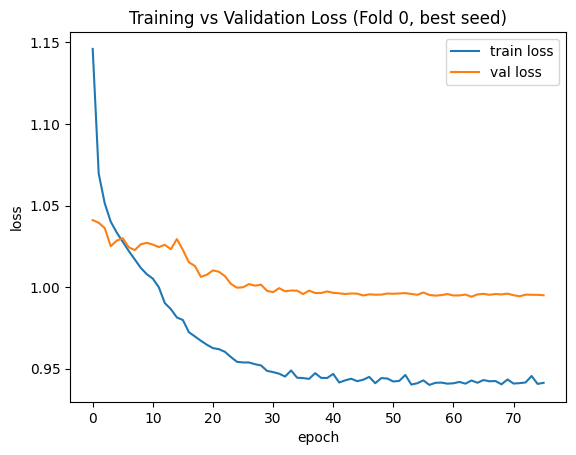

In [161]:
import matplotlib.pyplot as plt

hist0 = histories[0].history  # History object
plt.figure()
plt.plot(hist0["loss"], label="train loss")
plt.plot(hist0["val_loss"], label="val loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.title("Training vs Validation Loss (Fold 0, best seed)")
plt.show()


In [ ]:
config = {
    "hidden_units": (128, 64),
    "activation": "relu",      # or "leaky_relu"
    "dropout": 0.2,
    "batchnorm": True,
    "l2": 1e-4,

    "optimizer": "adamw",
    "lr": 1e-3,
    "weight_decay": 1e-4,

    "batch_size": 256,
    "max_epochs": 150,
    "patience": 12,
    "init": "he_normal"
}

metrics_per_fold = run_kfold_cv_keras(X_norm, y_onehot, folds, config, seeds=(0,1,2), verbose=0)



Fold 0: best seed=1 | f1_macro=0.4585 | acc=0.5162
Fold 1: best seed=0 | f1_macro=0.4629 | acc=0.5247


KeyboardInterrupt: 

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.title("Training vs Validation Loss (example fold)")
plt.show()


# Section 3: Tuning Hyper-parameters 
In this section, parameters including learning rate, weight decay and batch size will be tuned to explore their impacts on the model's performance. 

Stage 1: “big wins” search (capacity + LR + dropout)

Stage 2: fine tuning (regularisation / optimiser)

In [ ]:

import itertools
import pandas as pd

def tune_configs(X, Y, folds, base_config, seeds=(0,1,2), verbose=0):
    results = []

    for cfg in config_grid(base_config):
        final_fold_metrics = run_kfold_cv_keras(X, y_onehot, folds, cfg, seeds=(0,1,2), verbose=0)

        f1s = [m["f1_macro"] for m in final_fold_metrics]
        accs = [m["accuracy"] for m in final_fold_metrics]

        results.append({
            "f1_macro_mean": float(np.mean(f1s)),
            "f1_macro_std":  float(np.std(f1s)),
            "acc_mean":      float(np.mean(accs)),
            "acc_std":       float(np.std(accs)),
            **cfg
        })

    df = pd.DataFrame(results).sort_values("f1_macro_mean", ascending=False)
    return df

def config_grid(base):
    hidden_list = [(128,64), (256,128), (128,64,32)]
    lr_list = [1e-3, 3e-4]
    dropout_list = [0.1, 0.3]

    for hu, lr, dr in itertools.product(hidden_list, lr_list, dropout_list):
        cfg = dict(base)
        cfg["hidden_units"] = hu
        cfg["lr"] = lr
        cfg["dropout"] = dr
        yield cfg

base_config = {
    "hidden_units": (128, 64),
    "activation": "relu",
    "dropout": 0.2,
    "batchnorm": True,
    "l2": 1e-4,

    "optimizer": "adamw",
    "lr": 1e-3,
    "weight_decay": 1e-4,

    "batch_size": 256,
    "max_epochs": 150,
    "patience": 12,
    "init": "he_normal"
}

df_results = tune_configs(X_norm, y_onehot, folds, base_config, seeds=(0,1,2), verbose=0)
display(df_results.head(10))


KeyboardInterrupt: 

In [ ]:
# ----------------------------
# A1) Define the FINAL config
# ----------------------------
final_config = {
    "hidden_units": (256, 128),     # keep simple unless you found a better one
    "activation": "relu",
    "dropout": 0.3,
    "batchnorm": True,
    "l2": 1e-4,

    "optimizer": "adamw",
    "lr": 0.0003,
    "weight_decay": 1e-4,

    "batch_size": 256,
    "max_epochs": 150,
    "patience": 12,
    "init": "he_normal"
}

# ----------------------------
# A2) Run 10-fold CV once
# ----------------------------
final_fold_metrics = run_kfold_cv_keras(
    X_norm, y_onehot, folds,
    final_config,
    seeds=(0,1,2),
    verbose=0
)

# ----------------------------
# A3) Summarise into a table
# ----------------------------
import pandas as pd
import numpy as np

df_final = pd.DataFrame([{
    "fold": m["fold"],
    "seed": m["seed"],
    "f1_macro": m["f1_macro"],
    "accuracy": m["accuracy"],
    "precision_macro": m["precision_macro"],
    "recall_macro": m["recall_macro"],
    "f1_weighted": m["f1_weighted"],
} for m in final_fold_metrics])

display(df_final)

print("\n=== FINAL 10-FOLD SUMMARY (Report this) ===")
print(f"Macro-F1: {df_final['f1_macro'].mean():.4f} ± {df_final['f1_macro'].std():.4f}")
print(f"Accuracy: {df_final['accuracy'].mean():.4f} ± {df_final['accuracy'].std():.4f}")
print(f"F1-weighted: {df_final['f1_weighted'].mean():.4f} ± {df_final['f1_weighted'].std():.4f}")


Fold 0: best seed=2 | f1_macro=0.4581 | acc=0.5147
Fold 1: best seed=2 | f1_macro=0.4596 | acc=0.5171
Fold 2: best seed=1 | f1_macro=0.4606 | acc=0.5180
Fold 3: best seed=1 | f1_macro=0.4591 | acc=0.5175
Fold 4: best seed=0 | f1_macro=0.4623 | acc=0.5228
Fold 5: best seed=0 | f1_macro=0.4578 | acc=0.5145
Fold 6: best seed=0 | f1_macro=0.4540 | acc=0.5125
Fold 7: best seed=2 | f1_macro=0.4601 | acc=0.5193
Fold 8: best seed=0 | f1_macro=0.4616 | acc=0.5259
Fold 9: best seed=0 | f1_macro=0.4590 | acc=0.5161

=== CV Summary === Arch=(256, 128) | lr=0.0003 | dropout=0.3
Macro-F1: 0.4592 ± 0.0022
Accuracy: 0.5179 ± 0.0038


,fold,seed,f1_macro,accuracy,precision_macro,recall_macro,f1_weighted
0,0,2,0.458134,0.514709,0.464420,0.480781,0.535392
1,1,2,0.459581,0.517115,0.463943,0.487392,0.536544
2,2,1,0.460555,0.518009,0.462794,0.480938,0.535150
3,3,1,0.459074,0.517508,0.464785,0.487065,0.538144
4,4,0,0.462259,0.522786,0.465773,0.485932,0.538674
5,5,0,0.457833,0.514548,0.462996,0.486386,0.534436
6,6,0,0.454034,0.512535,0.464086,0.480996,0.536492
7,7,2,0.460064,0.519272,0.461886,0.482532,0.536901
8,8,0,0.461561,0.525942,0.461653,0.480097,0.541306
9,9,0,0.458993,0.516101,0.463953,0.478614,0.535260



=== FINAL 10-FOLD SUMMARY (Report this) ===
Macro-F1: 0.4592 ± 0.0023
Accuracy: 0.5179 ± 0.0040
F1-weighted: 0.5368 ± 0.0021


In [ ]:
# Your multiclass_metrics already returns per-class metrics arrays:
# precision_per_class, recall_per_class, f1_per_class, support_per_class

class_names = ["<30", ">30", "NO"]  # matches your label_map order

per_class_rows = []
for m in final_fold_metrics:
    for i, cname in enumerate(class_names):
        per_class_rows.append({
            "fold": m["fold"],
            "class": cname,
            "precision": float(m["precision_per_class"][i]),
            "recall": float(m["recall_per_class"][i]),
            "f1": float(m["f1_per_class"][i]),
            "support": float(m["support_per_class"][i]),
        })

df_pc = pd.DataFrame(per_class_rows)

# Mean ± std per class (THIS is very report-friendly)
df_pc_summary = df_pc.groupby("class")[["precision","recall","f1"]].agg(["mean","std"])
display(df_pc_summary)

# Optionally print a clean text version
print("\n=== PER-CLASS SUMMARY (mean ± std over folds) ===")
for cname in class_names:
    sub = df_pc[df_pc["class"] == cname]
    print(f"{cname:>3} | "
          f"P {sub['precision'].mean():.3f}±{sub['precision'].std():.3f}  "
          f"R {sub['recall'].mean():.3f}±{sub['recall'].std():.3f}  "
          f"F1 {sub['f1'].mean():.3f}±{sub['f1'].std():.3f}")


precision              recall                  f1          
           mean       std      mean       std      mean       std
class                                                            
<30    0.205653  0.009182  0.415074  0.022133  0.274728  0.008959
>30    0.479410  0.007751  0.452944  0.019751  0.465568  0.010985
NO     0.705823  0.007026  0.581202  0.014600  0.637330  0.007144


=== PER-CLASS SUMMARY (mean ± std over folds) ===
<30 | P 0.206±0.009  R 0.415±0.022  F1 0.275±0.009
>30 | P 0.479±0.008  R 0.453±0.020  F1 0.466±0.011
 NO | P 0.706±0.007  R 0.581±0.015  F1 0.637±0.007
